# Kernel SVM Cuántico (QKSVM)

Clasificación binaria sobre el dataset Iris usando una Máquina de Vectores de Soporte cuyo kernel
se calcula mediante un circuito cuántico.

Los resultados se guardan en `qksvm_results.json` para su uso en `comparison/comparison.ipynb`.

---

## Cómo funciona un Kernel SVM Cuántico

Un SVM clásico con kernel personalizado trabaja en dos pasos:

1. **Calcular la matriz del kernel** `K[i,j] = k(x_i, x_j)` para cada par de puntos de entrenamiento.
   Esta matriz codifica la similitud entre cada par de puntos en el espacio de características inducido por el kernel.
2. **Entrenar el SVM** usando esa matriz. El optimizador del SVM solo ve `K`, nunca los datos en bruto.

En el Kernel SVM Cuántico, el paso 1 se reemplaza por un circuito cuántico:

- Cada dato `x` se codifica en un estado cuántico `|φ(x)⟩` usando un **circuito de mapa de características**.
- El valor del kernel entre dos puntos es el solapamiento cuadrático (fidelidad) de sus estados cuánticos:
  `k(x_i, x_j) = |⟨φ(x_i)|φ(x_j)⟩|²`
- Se estima ejecutando un circuito que prepara `|φ(x_i)⟩`, aplica la inversa del circuito para
  `|φ(x_j)⟩`, y mide la probabilidad del resultado todo ceros `|0...0⟩`.

El paso 2 es completamente clásico — el SVM se entrena sobre la matriz del kernel cuántico exactamente
como se entrenaría sobre una matriz de kernel RBF.

**Diferencia clave respecto al VQC:** el circuito cuántico no tiene parámetros entrenables.
No hay descenso de gradiente. El circuito es fijo; solo se entrena el SVM.

---

**Variable de configuración:** `N_FEATURES` controla cuántas características (y qubits) se usan.  
**Hardware:** el cálculo del kernel se ejecuta en el simulador Aer. Activa `RUN_ON_REAL_HW = True`
para recomputar la matriz del kernel de test en IBM Quantum hardware.

## Importaciones

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import BackendSamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

## Configuración

In [2]:
N_FEATURES     = 2       # 2 or 4 — must match svm.ipynb
TEST_SIZE      = 0.2     # must match svm.ipynb
RANDOM_SEED    = 42      # must match svm.ipynb
RUN_ON_REAL_HW = False    # set True to recompute test kernel on IBM Quantum

RESULTS_FILE = "qksvm_results.json" if N_FEATURES == 2 else "qksvm_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, RUN_ON_REAL_HW={RUN_ON_REAL_HW}")
print(f"Results will be saved to: {RESULTS_FILE}")


Configuration: N_FEATURES=4, RUN_ON_REAL_HW=False
Results will be saved to: qksvm_results_4f.json


## Dataset

Preprocesamiento idéntico a `svm.ipynb` — misma semilla, misma partición, mismo escalado.
Las características se escalan a [0, π] para cubrir el rango completo de las puertas de rotación del mapa de características.

In [3]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler      = MinMaxScaler()
X_scaled    = scaler.fit_transform(X)
X_scaled_pi = X_scaled * np.pi   # scale to [0, π] for rotation gates

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Kernel Cuántico — Mapa de Características

Se usa `ZZFeatureMap` con `reps=2`, el mismo circuito que en el experimento VQC.
Esto hace que los dos experimentos cuánticos sean directamente comparables en términos de estructura del circuito.

El valor del kernel `k(x_i, x_j)` se estima como la probabilidad de medir `|0...0⟩`
tras ejecutar el circuito `U(x_j)† U(x_i)`, donde `U(x)` es el mapa de características aplicado a `x`.
Un valor cercano a 1 significa que los dos puntos se mapean a estados cuánticos muy similares (alta similitud);
un valor cercano a 0 significa que son casi ortogonales en el espacio de características cuántico (baja similitud).

Number of qubits : 4
Feature map      : ZZFeatureMap (reps=2)
Trainable params : 0  (kernel is fixed — no gradient descent)


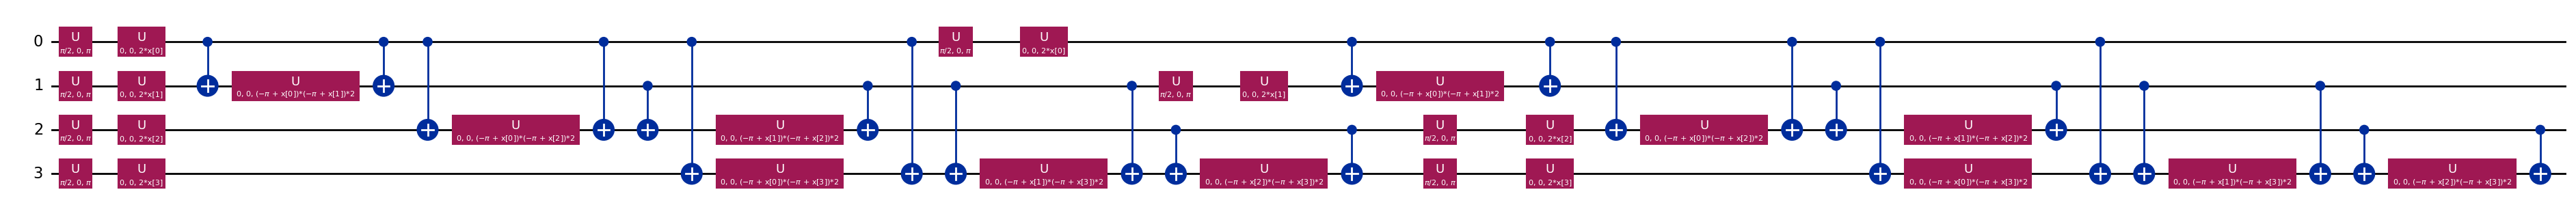

In [4]:
n_qubits    = N_FEATURES
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=2)

print(f"Number of qubits : {n_qubits}")
print(f"Feature map      : ZZFeatureMap (reps=2)")
print(f"Trainable params : 0  (kernel is fixed — no gradient descent)")
feature_map.decompose().draw(output="mpl", fold=-1)

## Calcular Matrices del Kernel en el Simulador Aer

Se necesitan dos matrices del kernel:
- **Kernel de entrenamiento** `K_train[i,j] = k(x_train_i, x_train_j)` — usado para ajustar el SVM.
- **Kernel de test** `K_test[i,j] = k(x_test_i, x_train_j)` — usado para predecir.

Para `n_train` puntos de entrenamiento, el kernel de entrenamiento requiere `n_train*(n_train+1)/2` evaluaciones
de circuito (matriz simétrica). El kernel de test requiere `n_test * n_train` evaluaciones.
Este es el coste computacional principal del QKSVM.

Nota: `FidelityQuantumKernel` gestiona automáticamente la construcción y evaluación de los circuitos.

In [5]:
backend  = AerSimulator()
pm       = generate_preset_pass_manager(backend=backend, optimization_level=1)
sampler  = BackendSamplerV2(backend=backend)
fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

print("Computing train kernel matrix...")
t0 = time.perf_counter()
K_train = quantum_kernel.evaluate(x_vec=X_train)
kernel_train_time = time.perf_counter() - t0
print(f"  Done in {kernel_train_time:.2f} s  — shape: {K_train.shape}")

print("Computing test kernel matrix...")
t0 = time.perf_counter()
K_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)
kernel_test_time = time.perf_counter() - t0
print(f"  Done in {kernel_test_time:.2f} s  — shape: {K_test.shape}")

total_kernel_time = kernel_train_time + kernel_test_time
print(f"\nTotal kernel computation time: {total_kernel_time:.2f} s")

Computing train kernel matrix...


  Done in 15.88 s  — shape: (80, 80)
Computing test kernel matrix...


  Done in 8.09 s  — shape: (20, 80)

Total kernel computation time: 23.98 s


## Entrenar el SVM sobre el Kernel Cuántico

Se pasa la matriz del kernel precomputada directamente al SVM usando `kernel='precomputed'`.
El SVM trata `K_train` como su matriz de Gram y optimiza los vectores de soporte
y la frontera de decisión — paso completamente clásico.

In [6]:
qksvm = SVC(kernel="precomputed", C=1.0, random_state=RANDOM_SEED)

t0 = time.perf_counter()
qksvm.fit(K_train, y_train)
svm_train_time = time.perf_counter() - t0

print(f"SVM training time (on quantum kernel): {svm_train_time:.4f} s")
print(f"Number of support vectors: {sum(qksvm.n_support_)}")

SVM training time (on quantum kernel): 0.0017 s
Number of support vectors: 73


## Evaluación en el Simulador

In [7]:
y_pred_train_sim = qksvm.predict(K_train)
y_pred_test_sim  = qksvm.predict(K_test)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print(f"Train accuracy (simulator): {acc_train_sim:.4f}")
print(f"Test accuracy  (simulator): {acc_test_sim:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))

Train accuracy (simulator): 0.9500
Test accuracy  (simulator): 0.6500

              precision    recall  f1-score   support

  Versicolor       0.64      0.70      0.67        10
   Virginica       0.67      0.60      0.63        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20



## Análisis de Ruido del Kernel en IBM Quantum Hardware (opcional)

Se usa un **subconjunto demo** de 10 puntos (5 por clase de X_train) para calcular el kernel cuántico
tanto en el simulador Aer como en IBM Quantum hardware. La comparación lado a lado muestra cómo
el ruido del hardware distorsiona los valores del kernel respecto al caso ideal (sin ruido).

Calcular el kernel de test completo (20 × 80 = 1 600 pares) requeriría ~29 min en IBM Open Plan
(presupuesto: 10 min/mes). El demo de 10 × 10 (55 pares únicos, ~2 trabajos) se ejecuta en ~2 minutos.

Activa `RUN_ON_REAL_HW = True` en la celda de Configuración para habilitar esta sección.

In [8]:
backend_name     = None
kernel_real_time = None
K_demo_sim       = None
K_demo_real      = None
kernel_corr      = None
kernel_mae       = None
N_DEMO           = 5   # points per class → 10 total, 55 unique pairs → ~2 jobs on IBM Open Plan

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RealSampler

    # Stratified demo subset: N_DEMO points per class from X_train
    idx_c0 = np.where(y_train == 0)[0][:N_DEMO]
    idx_c1 = np.where(y_train == 1)[0][:N_DEMO]
    X_demo = X_train[np.concatenate([idx_c0, idx_c1])]
    y_demo = y_train[np.concatenate([idx_c0, idx_c1])]
    print(f"Demo subset: {len(X_demo)} points ({N_DEMO} per class), class balance: {np.bincount(y_demo)}")

    # Simulator kernel for the same subset (reference — no IBM quota used)
    print("Computing demo kernel on Aer simulator...")
    K_demo_sim = quantum_kernel.evaluate(x_vec=X_demo)
    print(f"  Done — shape: {K_demo_sim.shape}")

    # Real hardware kernel
    service      = QiskitRuntimeService()
    backend      = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    real_pm       = generate_preset_pass_manager(backend=backend, optimization_level=1)
    real_sampler  = RealSampler(backend)
    real_fidelity = ComputeUncompute(sampler=real_sampler, pass_manager=real_pm)

    # Open Plan: no Sessions (error 1352). max_circuits_per_job=50 avoids per-job limit (error 1305).
    quantum_kernel_real = FidelityQuantumKernel(
        feature_map=feature_map,
        fidelity=real_fidelity,
        max_circuits_per_job=50,
    )

    print("Computing demo kernel on real hardware (~2 jobs, ≤55 circuits total)...")
    t0               = time.perf_counter()
    K_demo_real      = quantum_kernel_real.evaluate(x_vec=X_demo)
    kernel_real_time = time.perf_counter() - t0
    print(f"  Done in {kernel_real_time:.2f} s — shape: {K_demo_real.shape}")

    # Noise characterisation: element-wise comparison of simulator vs real kernel
    kernel_corr = float(np.corrcoef(K_demo_sim.ravel(), K_demo_real.ravel())[0, 1])
    kernel_mae  = float(np.mean(np.abs(K_demo_sim - K_demo_real)))
    print(f"Kernel Pearson r (sim vs real) : {kernel_corr:.4f}")
    print(f"Kernel MAE       (sim vs real) : {kernel_mae:.4f}")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")

RUN_ON_REAL_HW is False — skipping real hardware evaluation.
Set RUN_ON_REAL_HW = True in the Configuration cell to enable.


## Análisis de Ruido del Kernel — Simulador vs Hardware Real

Comparación lado a lado de la matriz del kernel cuántico 10×10 en el simulador Aer y en IBM Quantum hardware.
La matriz de diferencias revela dónde el ruido del hardware distorsiona más los valores del kernel.

**Pearson r** cercano a 1 significa que el hardware real reproduce fielmente la estructura ideal del kernel a pesar del ruido.  
**MAE** cuantifica el error absoluto medio por entrada del kernel.

In [9]:
if RUN_ON_REAL_HW and K_demo_real is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    matrices = [K_demo_sim, K_demo_real, K_demo_sim - K_demo_real]
    titles   = ["Kernel del simulador", "Kernel del hardware real", "Diferencia (sim − real)"]
    cmaps    = ["viridis", "viridis", "coolwarm"]
    vmins    = [0, 0, -0.5]
    vmaxs    = [1, 1,  0.5]

    for ax, mat, title, cmap, vmin, vmax in zip(axes, matrices, titles, cmaps, vmins, vmaxs):
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Índice de punto")
        ax.set_ylabel("Índice de punto")
        plt.colorbar(im, ax=ax)

    plt.suptitle(
        f"Análisis de Ruido del Kernel Cuántico — ZZFeatureMap {n_qubits}q, {N_DEMO * 2} puntos demo\n"
        f"Pearson r = {kernel_corr:.4f}   MAE = {kernel_mae:.4f}   Backend: {backend_name}"
    )
    plt.tight_layout()
    plt.savefig(f"qksvm_kernel_noise{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
    plt.show()
else:
    print("Kernel noise plot skipped (RUN_ON_REAL_HW is False or real HW run did not complete).")

Kernel noise plot skipped (RUN_ON_REAL_HW is False or real HW run did not complete).


## Gráficas

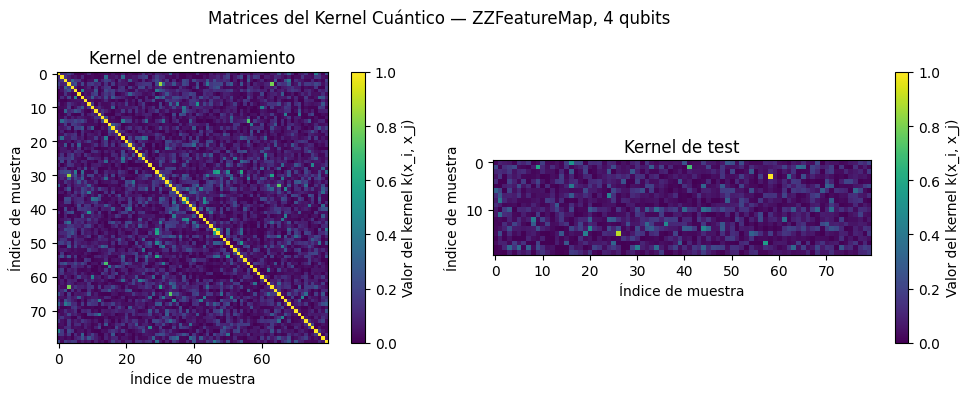

In [10]:
# --- Kernel matrix heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, matrix, title in zip(axes,
                               [K_train, K_test],
                               ["Kernel de entrenamiento", "Kernel de test"]):
    im = ax.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Índice de muestra")
    ax.set_ylabel("Índice de muestra")
    plt.colorbar(im, ax=ax, label="Valor del kernel k(x_i, x_j)")

plt.suptitle(f"Matrices del Kernel Cuántico — ZZFeatureMap, {n_qubits} qubits")
plt.tight_layout()
plt.savefig(f"qksvm_kernel_matrices{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

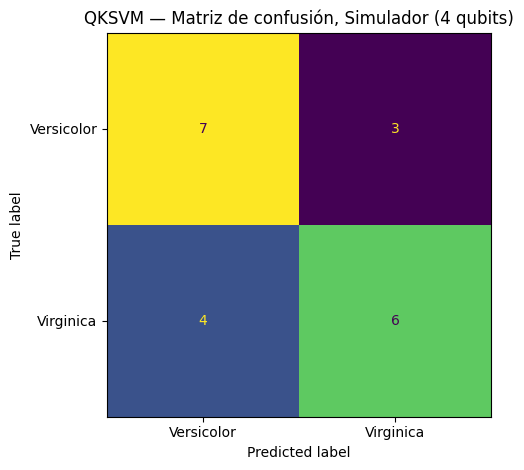

In [11]:
# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"QKSVM — Matriz de confusión, Simulador ({N_FEATURES} qubits)")
plt.tight_layout()
plt.savefig(f"qksvm_confusion_matrix_sim{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

In [12]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.20   # coarser grid — quantum kernel evaluation is O(n_grid * n_train) circuits
    xx, yy  = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid    = np.c_[xx.ravel(), yy.ravel()]

    # Kernel between grid points and training points
    K_grid  = quantum_kernel.evaluate(x_vec=grid, y_vec=X_train)
    Z       = qksvm.predict(K_grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Entrenamiento")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Prueba")
    plt.colorbar(scatter, ticks=[0, 1], label="Clase")
    plt.xlabel("longitud del pétalo (escalada × π)")
    plt.ylabel("anchura del pétalo  (escalada × π)")
    plt.title("QKSVM — Frontera de decisión (2 qubits, simulador Aer)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qksvm_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

Decision boundary plot skipped (only available for N_FEATURES=2).


## Guardar Resultados

In [13]:
results = {
    # --- Experiment metadata ---
    "model"                 : "QKSVM",
    "n_features"            : N_FEATURES,
    "n_qubits"              : n_qubits,
    "feature_names"         : feature_names,
    "n_train"               : int(len(X_train)),
    "n_test"                : int(len(X_test)),
    "random_seed"           : RANDOM_SEED,
    # --- Circuit architecture ---
    "feature_map"           : "ZZFeatureMap",
    "feature_map_reps"      : 2,
    "n_trainable_params"    : 0,
    # --- Timing ---
    "kernel_train_time_s"   : float(kernel_train_time),
    "kernel_test_time_s"    : float(kernel_test_time),
    "total_kernel_time_s"   : float(total_kernel_time),
    "svm_train_time_s"      : float(svm_train_time),
    "total_time_s"          : float(total_kernel_time + svm_train_time),
    # --- Accuracy (simulator) ---
    "accuracy_test_sim"     : float(acc_test_sim),
    "accuracy_train_sim"    : float(acc_train_sim),
    # --- SVM details ---
    "n_support_vectors"     : int(sum(qksvm.n_support_)),
    "svm_C"                 : qksvm.C,
    # --- Predictions (simulator) ---
    "y_test"                : y_test.tolist(),
    "y_pred_test_sim"       : y_pred_test_sim.tolist(),
    # --- Real hardware (kernel noise demo) ---
    "real_hw_run"           : RUN_ON_REAL_HW and K_demo_real is not None,
    "backend_name"          : backend_name,
    "kernel_demo_n"         : (N_DEMO * 2) if K_demo_real is not None else None,
    "kernel_real_time_s"    : float(kernel_real_time) if kernel_real_time is not None else None,
    "kernel_corr_sim_real"  : kernel_corr,
    "kernel_mae_sim_real"   : kernel_mae,
    "K_demo_sim"            : K_demo_sim.tolist() if K_demo_sim is not None else None,
    "K_demo_real"           : K_demo_real.tolist() if K_demo_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
summary_keys = [k for k in results if k not in ("y_test", "y_pred_test_sim", "K_demo_sim", "K_demo_real")]
print(json.dumps({k: results[k] for k in summary_keys}, indent=2))

Results saved to qksvm_results_4f.json
{
  "model": "QKSVM",
  "n_features": 4,
  "n_qubits": 4,
  "feature_names": [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 2,
  "n_trainable_params": 0,
  "kernel_train_time_s": 15.881254908999836,
  "kernel_test_time_s": 8.094480704996386,
  "total_kernel_time_s": 23.97573561399622,
  "svm_train_time_s": 0.001652965998800937,
  "total_time_s": 23.977388579995022,
  "accuracy_test_sim": 0.65,
  "accuracy_train_sim": 0.95,
  "n_support_vectors": 73,
  "svm_C": 1.0,
  "real_hw_run": false,
  "backend_name": null,
  "kernel_demo_n": null,
  "kernel_real_time_s": null,
  "kernel_corr_sim_real": null,
  "kernel_mae_sim_real": null
}
